
# Supervised Deep Learning for P/S Arrival Picking from 3-Component Seismograms

This notebook provides a **runnable, end-to-end supervised learning workflow** for training a neural network to pick **both P-wave and S-wave arrival times** from **3-component seismograms**.

The dataset is assumed to be stored in a NumPy archive:

```python
SWAN_real_arrival.npz
```

with keys:

- `waveforms`: shape `(N, 6000, 3)`
- `P`: shape `(N,)`
- `S`: shape `(N,)`
- `ids`: shape `(N,)` (optional but recommended)

---

## What this notebook includes

- dataset loading and sanity checking
- exploratory visualization of 3-component waveforms
- target construction for supervised phase picking
- a **1D U-Net–style neural network**
- training / validation / test split with user control
- loss functions and mathematical explanation
- performance evaluation in **samples** and **seconds**
- prediction visualization with probability curves
- professional plots for learning curves and qualitative examples

---

## Problem statement

Given a 3-component waveform

$$
\mathbf{x}(t) = [x_Z(t),\, x_N(t),\, x_E(t)]^\top,\quad t=1,\dots,T,
$$

we want to learn a nonlinear mapping

$$
f_\theta: \mathbb{R}^{3 \times T} \rightarrow \mathbb{R}^{2 \times T},
$$

where the output contains two probability curves:

- $p_P(t)$: probability that sample $t$ is the **P arrival**
- $p_S(t)$: probability that sample $t$ is the **S arrival**

The final picks are obtained as

$$
\hat{t}_P = \arg\max_t p_P(t), \qquad
\hat{t}_S = \arg\max_t p_S(t).
$$

Because exact arrivals are discrete impulses and difficult to learn directly, we represent the labels as **soft Gaussian targets** centered on the annotated arrivals.

For a true P arrival at sample $t_P$, the target curve is

$$
y_P(t) = \exp\left(-\frac{(t-t_P)^2}{2\sigma^2}\right),
$$

and similarly for S:

$$
y_S(t) = \exp\left(-\frac{(t-t_S)^2}{2\sigma^2}\right).
$$

This converts picking into a **dense sequence labeling** problem.

---

## Why this formulation works well

Compared with regressing directly to two integers $(t_P,t_S)$, probability-curve prediction has several advantages:

1. it gives a smoother and easier optimization target,
2. it preserves uncertainty information,
3. it naturally supports visualization and confidence estimation,
4. it resembles widely used phase-picking strategies such as **PhaseNet-style** workflows.

---

## Dataset reminder

This notebook is designed for the educational dataset **SWAN_real_arrival**, which contains:

- **100,000** samples
- **6000** time samples per waveform
- **3 components**: Z / N / E
- **100 Hz sampling rate**
- **P and S sample indices**

At 100 Hz, one sample corresponds to

$$
\Delta t = 0.01\ \text{s}.
$$


In [1]:

# =========================
# 1. Imports and settings
# =========================
import os
import math
import random
import warnings
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

warnings.filterwarnings("ignore")

# Plot style
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda



## User configuration

The main controls below let you change:

- the dataset path
- train / validation / test ratios
- the number of samples used
- batch size and learning rate
- Gaussian label width
- training epochs

For quick experimentation, you can reduce `MAX_SAMPLES`. For final runs, set it to `None` to use the whole dataset.


In [2]:

# =========================
# 2. User configuration
# =========================
@dataclass
class Config:
    npz_path: str = "../dataset/SWAN_real_arrival.npz"
    sampling_rate: float = 100.0
    max_samples: int | None = 100000   # set to None to use all samples
    train_ratio: float = 0.80
    valid_ratio: float = 0.10
    test_ratio: float = 0.10
    batch_size: int = 32
    num_workers: int = 0
    epochs: int = 30
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    gaussian_sigma: float = 12.0      # label width in samples
    tolerance_samples: tuple = (10, 20, 50)
    normalize_mode: str = "per_trace" # "per_trace" or "global"
    use_amp_jitter: bool = True
    amp_jitter_range: tuple = (0.9, 1.1)
    clip_value: float | None = 6.0
    save_best_model: str = "arrival_picker_unet1d_best.pt"

cfg = Config()
print(cfg)


Config(npz_path='../dataset/SWAN_real_arrival.npz', sampling_rate=100.0, max_samples=100000, train_ratio=0.8, valid_ratio=0.1, test_ratio=0.1, batch_size=32, num_workers=0, epochs=30, learning_rate=0.001, weight_decay=1e-05, gaussian_sigma=12.0, tolerance_samples=(10, 20, 50), normalize_mode='per_trace', use_amp_jitter=True, amp_jitter_range=(0.9, 1.1), clip_value=6.0, save_best_model='arrival_picker_unet1d_best.pt')



## Data loading and sanity checks

We now load the `.npz` file and verify the expected structure.

Expected shapes:

- `waveforms`: `(N, 6000, 3)`
- `P`: `(N,)`
- `S`: `(N,)`

We also check for:

- invalid arrival indices
- shape consistency
- obvious timing issues such as $t_S \le t_P$


In [3]:

# =========================
# 3. Load dataset
# =========================
assert os.path.exists(cfg.npz_path), f"File not found: {cfg.npz_path}"

data = np.load(cfg.npz_path, allow_pickle=True)
waveforms = data["waveforms"].astype(np.float32)
P_idx = data["P"].astype(np.int64)
S_idx = data["S"].astype(np.int64)
ids = data["ids"] if "ids" in data.files else np.arange(len(waveforms)).astype(str)

print("Keys:", data.files)
print("waveforms:", waveforms.shape, waveforms.dtype)
print("P:", P_idx.shape, P_idx.dtype)
print("S:", S_idx.shape, S_idx.dtype)
print("ids:", ids.shape)

N, T, C = waveforms.shape
assert C == 3, "Expected 3 components (Z, N, E)."
assert P_idx.shape[0] == N and S_idx.shape[0] == N

valid_mask = (
    (P_idx >= 0) & (P_idx < T) &
    (S_idx >= 0) & (S_idx < T)
)

print(f"Valid arrival indices: {valid_mask.sum():,} / {N:,}")

if valid_mask.sum() < N:
    waveforms = waveforms[valid_mask]
    P_idx = P_idx[valid_mask]
    S_idx = S_idx[valid_mask]
    ids = ids[valid_mask]
    N = len(waveforms)

ps_order = (S_idx > P_idx)
print(f"S after P: {ps_order.sum():,} / {N:,}")

if cfg.max_samples is not None:
    N_use = min(cfg.max_samples, N)
    rng = np.random.default_rng(SEED)
    chosen = rng.choice(N, size=N_use, replace=False)
    waveforms = waveforms[chosen]
    P_idx = P_idx[chosen]
    S_idx = S_idx[chosen]
    ids = ids[chosen]
    N = len(waveforms)

print("Using samples:", N)
print("Final waveform tensor:", waveforms.shape)


Keys: ['waveforms', 'P', 'S', 'ids']
waveforms: (100000, 6000, 3) float32
P: (100000,) int64
S: (100000,) int64
ids: (100000,)
Valid arrival indices: 100,000 / 100,000
S after P: 99,998 / 100,000
Using samples: 100000
Final waveform tensor: (100000, 6000, 3)



## Quick statistical summary

A few simple diagnostics are helpful before training:

- distribution of P arrivals
- distribution of S arrivals
- distribution of S–P time
- amplitude distribution

The S–P interval is physically meaningful and often correlates with source–receiver distance.


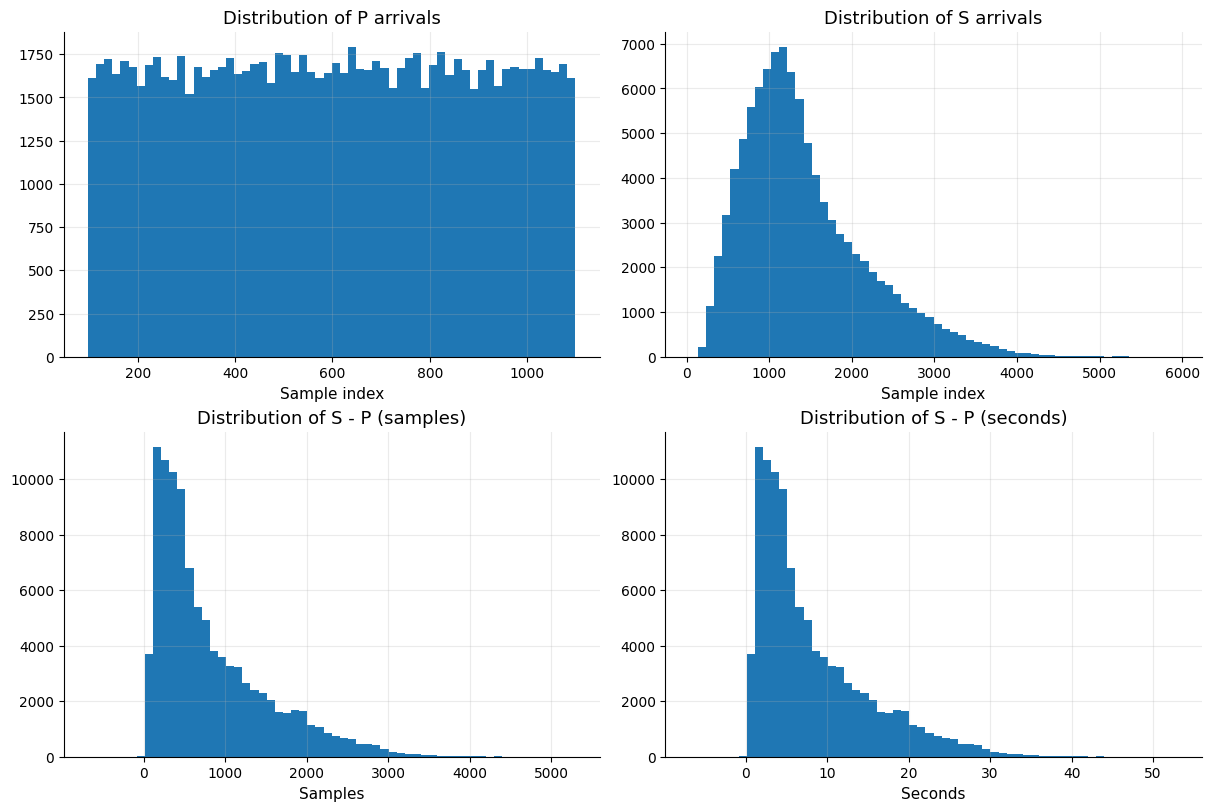

P range: 98 1099
S range: 38 5940
Mean S-P (samples): 820.41131
Mean S-P (seconds): 8.204113099999999


In [4]:

# =========================
# 4. Basic statistics
# =========================
dt = 1.0 / cfg.sampling_rate
sp_samples = S_idx - P_idx
sp_seconds = sp_samples * dt

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].hist(P_idx, bins=60)
axes[0, 0].set_title("Distribution of P arrivals")
axes[0, 0].set_xlabel("Sample index")

axes[0, 1].hist(S_idx, bins=60)
axes[0, 1].set_title("Distribution of S arrivals")
axes[0, 1].set_xlabel("Sample index")

axes[1, 0].hist(sp_samples, bins=60)
axes[1, 0].set_title("Distribution of S - P (samples)")
axes[1, 0].set_xlabel("Samples")

axes[1, 1].hist(sp_seconds, bins=60)
axes[1, 1].set_title("Distribution of S - P (seconds)")
axes[1, 1].set_xlabel("Seconds")

plt.show()

print("P range:", P_idx.min(), P_idx.max())
print("S range:", S_idx.min(), S_idx.max())
print("Mean S-P (samples):", float(np.mean(sp_samples)))
print("Mean S-P (seconds):", float(np.mean(sp_seconds)))



## Visualizing a few raw examples

Each sample is a matrix of shape `(6000, 3)`:

- channel 0: Z
- channel 1: N
- channel 2: E

Below we plot a few waveforms and mark the annotated P and S arrivals.

This is one of the most important quality-control steps before training.


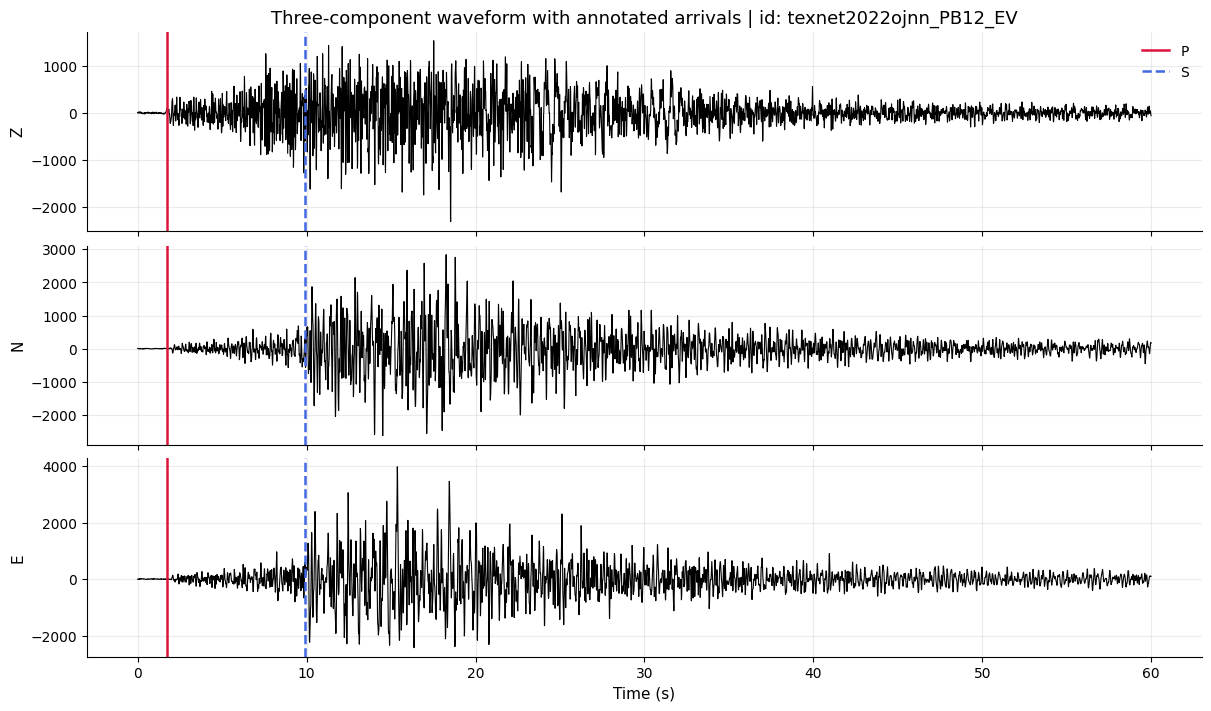

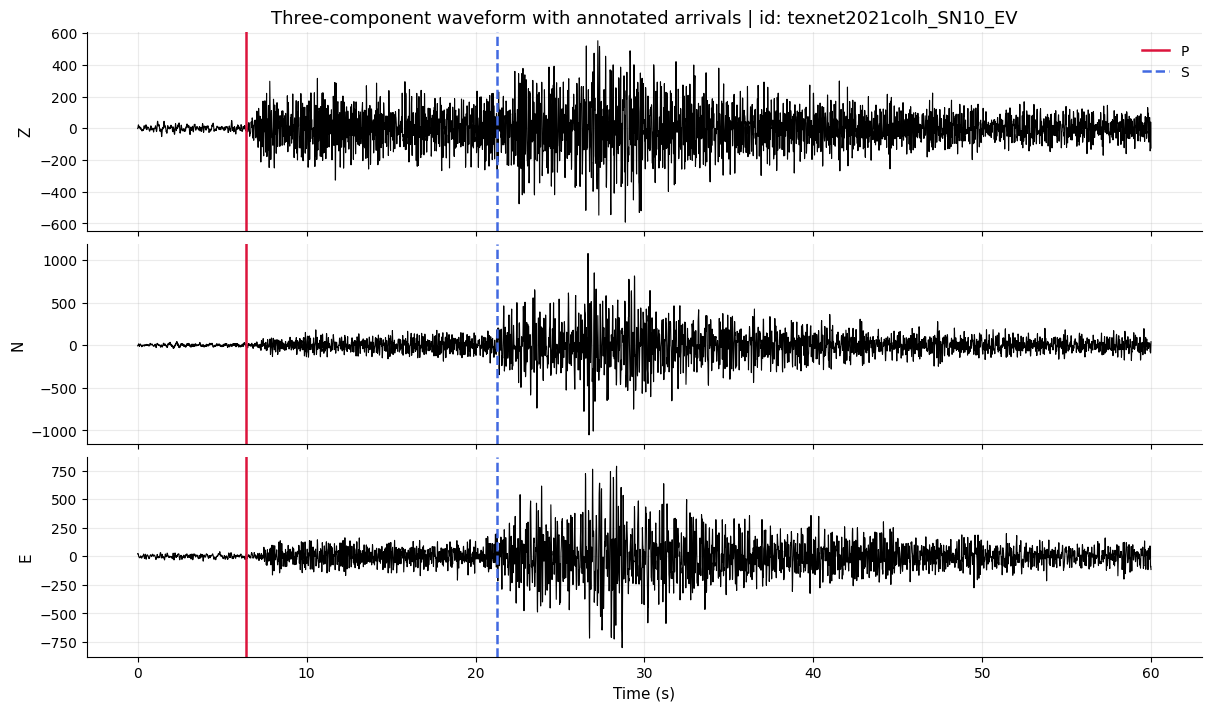

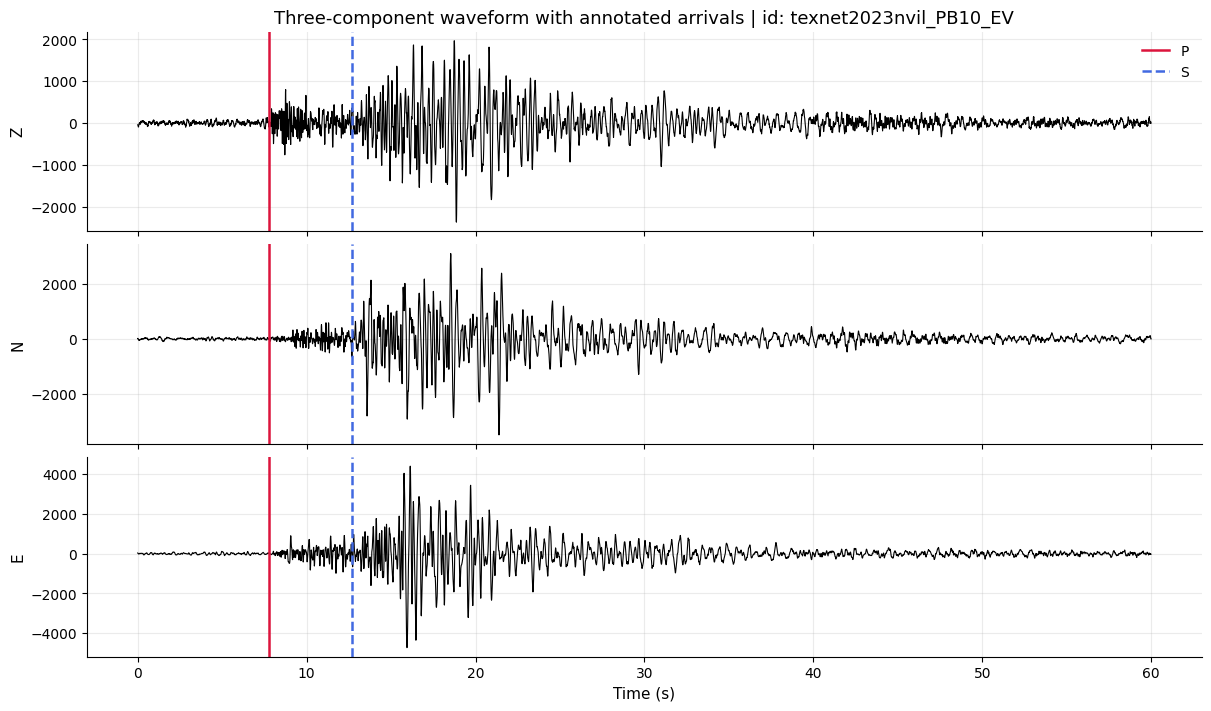

In [5]:

# =========================
# 5. Visualization helpers
# =========================
COMPONENT_NAMES = ["Z", "N", "E"]

def plot_waveform_sample(x, p, s, sample_id=None, fs=100.0):
    t = np.arange(len(x)) / fs
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 7), constrained_layout=True)

    for k in range(3):
        ax = axes[k]
        ax.plot(t, x[:, k], color="black", lw=0.8)
        ax.axvline(p / fs, color="crimson", lw=1.8, label="P" if k == 0 else None)
        ax.axvline(s / fs, color="royalblue", lw=1.8, ls="--", label="S" if k == 0 else None)
        ax.set_ylabel(COMPONENT_NAMES[k])
        if k == 0:
            ax.legend(frameon=False, loc="upper right")

    title = "Three-component waveform with annotated arrivals"
    if sample_id is not None:
        title += f" | id: {sample_id}"
    axes[0].set_title(title)
    axes[-1].set_xlabel("Time (s)")
    plt.show()

# show a few random examples
rng = np.random.default_rng(SEED)
example_ids = rng.choice(len(waveforms), size=3, replace=False)
for i in example_ids:
    plot_waveform_sample(waveforms[i], P_idx[i], S_idx[i], ids[i], cfg.sampling_rate)



## Label design: Gaussian target curves

Instead of predicting two integers directly, we build two smooth target curves:

- one for P
- one for S

If the true arrival is at sample $\tau$, the target is

$$
g_\tau(t) = \exp\left(-\frac{(t-\tau)^2}{2\sigma^2}\right).
$$

This helps the network learn local neighborhoods around the true arrival rather than only a single impulse sample.

The target tensor therefore has shape

$$
(2, T),
$$

where channel 0 is the P target and channel 1 is the S target.


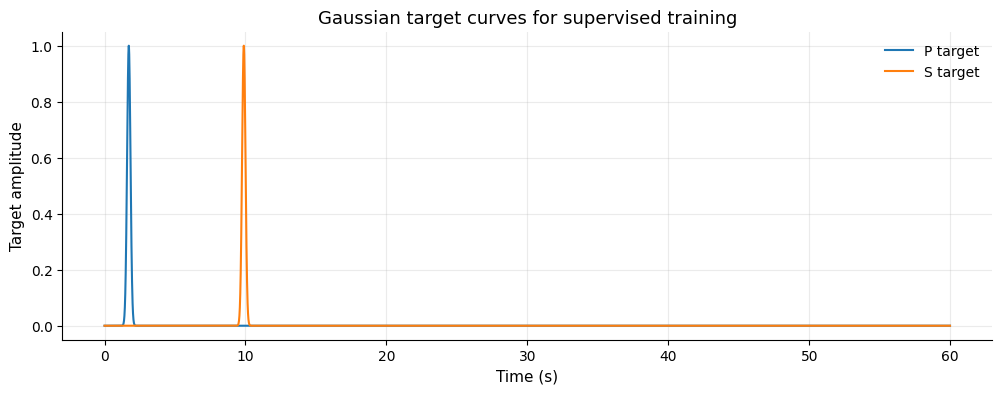

In [6]:

# =========================
# 6. Target construction
# =========================
def gaussian_pick_label(length, center, sigma):
    t = np.arange(length, dtype=np.float32)
    return np.exp(-0.5 * ((t - float(center)) / float(sigma)) ** 2).astype(np.float32)

# visualize target curves for one sample
i = example_ids[0]
target_p = gaussian_pick_label(T, P_idx[i], cfg.gaussian_sigma)
target_s = gaussian_pick_label(T, S_idx[i], cfg.gaussian_sigma)

tt = np.arange(T) / cfg.sampling_rate
plt.figure(figsize=(12, 4))
plt.plot(tt, target_p, label="P target")
plt.plot(tt, target_s, label="S target")
plt.xlabel("Time (s)")
plt.ylabel("Target amplitude")
plt.title("Gaussian target curves for supervised training")
plt.legend(frameon=False)
plt.show()



## Dataset class and preprocessing

A training sample is returned as:

- input waveform: shape `(3, T)`
- target curves: shape `(2, T)`
- discrete arrivals `(t_P, t_S)`

### Normalization

Per-trace normalization is a common choice in seismic deep learning because amplitude scales can vary substantially from trace to trace.  
For a waveform tensor $\mathbf{x}$, we normalize by

$$
\tilde{\mathbf{x}} = \frac{\mathbf{x} - \mu}{\sigma + \varepsilon},
$$

where $\mu$ and $\sigma$ are computed over the current waveform sample.

This improves optimization stability while preserving the waveform shape.

### Optional amplitude jitter

We also include mild amplitude scaling during training:

$$
\mathbf{x}_{\text{aug}} = a \, \tilde{\mathbf{x}},
\qquad a \sim \mathcal{U}(a_{\min}, a_{\max}),
$$

which improves robustness.


In [7]:

# =========================
# 7. Dataset class
# =========================
class ArrivalPickingDataset(Dataset):
    def __init__(self, waveforms, p_idx, s_idx, sigma=12.0, training=False, cfg=None):
        self.waveforms = waveforms.astype(np.float32)
        self.p_idx = p_idx.astype(np.int64)
        self.s_idx = s_idx.astype(np.int64)
        self.sigma = sigma
        self.training = training
        self.cfg = cfg

    def __len__(self):
        return len(self.waveforms)

    def _normalize(self, x):
        # x shape: (T, 3)
        mu = x.mean()
        std = x.std()
        x = (x - mu) / (std + 1e-6)
        if self.cfg.clip_value is not None:
            x = np.clip(x, -self.cfg.clip_value, self.cfg.clip_value)
        return x

    def _augment(self, x):
        if self.training and self.cfg.use_amp_jitter:
            lo, hi = self.cfg.amp_jitter_range
            a = np.random.uniform(lo, hi)
            x = x * a
        return x

    def __getitem__(self, idx):
        x = self.waveforms[idx].copy()               # (T, 3)
        p = int(self.p_idx[idx])
        s = int(self.s_idx[idx])

        x = self._normalize(x)
        x = self._augment(x)

        yp = gaussian_pick_label(x.shape[0], p, self.sigma)
        ys = gaussian_pick_label(x.shape[0], s, self.sigma)
        y = np.stack([yp, ys], axis=0)              # (2, T)

        x = torch.from_numpy(x.T).float()           # (3, T)
        y = torch.from_numpy(y).float()             # (2, T)

        meta = {
            "p": torch.tensor(p, dtype=torch.long),
            "s": torch.tensor(s, dtype=torch.long),
        }
        return x, y, meta



## Train / validation / test split

We split the dataset into three disjoint subsets:

- training set
- validation set
- test set

The validation set is used to monitor overfitting and select the best model.  
The test set is used only once for final evaluation.

If the total number of samples is $N$, then:

$$
N_{\text{train}} \approx r_{\text{train}} N,\qquad
N_{\text{valid}} \approx r_{\text{valid}} N,\qquad
N_{\text{test}} \approx r_{\text{test}} N.
$$


In [8]:

# =========================
# 8. Splits and loaders
# =========================
assert abs(cfg.train_ratio + cfg.valid_ratio + cfg.test_ratio - 1.0) < 1e-8

indices = np.arange(N)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

n_train = int(cfg.train_ratio * N)
n_valid = int(cfg.valid_ratio * N)
n_test = N - n_train - n_valid

idx_train = indices[:n_train]
idx_valid = indices[n_train:n_train+n_valid]
idx_test = indices[n_train+n_valid:]

train_ds = ArrivalPickingDataset(waveforms[idx_train], P_idx[idx_train], S_idx[idx_train],
                                 sigma=cfg.gaussian_sigma, training=True, cfg=cfg)
valid_ds = ArrivalPickingDataset(waveforms[idx_valid], P_idx[idx_valid], S_idx[idx_valid],
                                 sigma=cfg.gaussian_sigma, training=False, cfg=cfg)
test_ds  = ArrivalPickingDataset(waveforms[idx_test], P_idx[idx_test], S_idx[idx_test],
                                 sigma=cfg.gaussian_sigma, training=False, cfg=cfg)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)

print(f"Train: {len(train_ds):,}")
print(f"Valid: {len(valid_ds):,}")
print(f"Test : {len(test_ds):,}")


Train: 80,000
Valid: 10,000
Test : 10,000



## A 1D U-Net–style architecture

We use a compact **1D U-Net** because arrival picking is fundamentally a **temporal localization** problem.

### Input and output

- Input: waveform tensor of shape `(3, T)`
- Output: logits of shape `(2, T)`

The encoder progressively extracts multi-scale features, while the decoder restores temporal resolution and fuses coarse and fine information through skip connections.

### Conceptual mapping

$$
\mathbf{x} \in \mathbb{R}^{3 \times T}
\;\xrightarrow{\text{U-Net 1D}}\;
\mathbf{z} \in \mathbb{R}^{2 \times T}
\;\xrightarrow{\sigma(\cdot)}\;
\hat{\mathbf{y}} \in [0,1]^{2 \times T},
$$

where $\sigma$ is the sigmoid function applied elementwise.

This is appropriate because the target curves are dense probability-like functions.


In [9]:

# =========================
# 9. Model definition
# =========================
class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, k=7, p=3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=k, padding=p),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size=k, padding=p),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet1DPicker(nn.Module):
    def __init__(self, in_ch=3, out_ch=2, base=32):
        super().__init__()

        self.enc1 = ConvBlock1D(in_ch, base)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = ConvBlock1D(base, base*2)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = ConvBlock1D(base*2, base*4)
        self.pool3 = nn.MaxPool1d(2)

        self.bottleneck = ConvBlock1D(base*4, base*8)

        self.up3 = nn.ConvTranspose1d(base*8, base*4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock1D(base*8, base*4)

        self.up2 = nn.ConvTranspose1d(base*4, base*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock1D(base*4, base*2)

        self.up1 = nn.ConvTranspose1d(base*2, base, kernel_size=2, stride=2)
        self.dec1 = ConvBlock1D(base*2, base)

        self.head = nn.Conv1d(base, out_ch, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)             # (B, base, T)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b  = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        if d3.shape[-1] != e3.shape[-1]:
            d3 = F.interpolate(d3, size=e3.shape[-1], mode="linear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-1] != e2.shape[-1]:
            d2 = F.interpolate(d2, size=e2.shape[-1], mode="linear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-1] != e1.shape[-1]:
            d1 = F.interpolate(d1, size=e1.shape[-1], mode="linear", align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        logits = self.head(d1)        # (B, 2, T)
        return logits

model = UNet1DPicker(in_ch=3, out_ch=2, base=24).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable parameters: {n_params:,}")


UNet1DPicker(
  (enc1): ConvBlock1D(
    (block): Sequential(
      (0): Conv1d(3, 24, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(24, 24, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ConvBlock1D(
    (block): Sequential(
      (0): Conv1d(24, 48, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(48, 48, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool2): MaxPoo


## Loss function

Let the model output logits $\mathbf{z}$ and probabilities $\hat{\mathbf{y}} = \sigma(\mathbf{z})$.

We combine:

1. **binary cross-entropy with logits**
2. **soft Dice loss**

### BCE term

$$
\mathcal{L}_{\text{BCE}}
=
-\frac{1}{2T}
\sum_{c=1}^{2}\sum_{t=1}^{T}
\left[
y_{c,t}\log \hat{y}_{c,t}
+
(1-y_{c,t})\log(1-\hat{y}_{c,t})
\right].
$$

### Soft Dice term

For each channel $c$:

$$
\mathrm{Dice}_c
=
\frac{2\sum_t \hat{y}_{c,t} y_{c,t} + \epsilon}
{\sum_t \hat{y}_{c,t} + \sum_t y_{c,t} + \epsilon}.
$$

The Dice loss is

$$
\mathcal{L}_{\text{Dice}} = 1 - \frac{1}{2}\sum_{c=1}^{2}\mathrm{Dice}_c.
$$

### Total loss

$$
\mathcal{L}
=
\lambda_{\text{BCE}} \mathcal{L}_{\text{BCE}}
+
\lambda_{\text{Dice}} \mathcal{L}_{\text{Dice}}.
$$

This combination is effective because BCE gives stable local supervision and Dice emphasizes overlap of the predicted probability peaks with the target peaks.


In [10]:

# =========================
# 10. Loss and metrics
# =========================
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=1.0, dice_weight=1.0, eps=1e-6):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.eps = eps

    def forward(self, logits, target):
        bce = self.bce(logits, target)

        prob = torch.sigmoid(logits)
        # flatten over time, average over batch and channels
        inter = (prob * target).sum(dim=-1)
        denom = prob.sum(dim=-1) + target.sum(dim=-1)
        dice = (2.0 * inter + self.eps) / (denom + self.eps)
        dice_loss = 1.0 - dice.mean()

        total = self.bce_weight * bce + self.dice_weight * dice_loss
        return total, {"bce": bce.item(), "dice": dice_loss.item()}

criterion = BCEDiceLoss(bce_weight=1.0, dice_weight=1.0)

@torch.no_grad()
def picks_from_logits(logits):
    # logits: (B, 2, T)
    prob = torch.sigmoid(logits)
    p_pred = prob[:, 0, :].argmax(dim=-1)
    s_pred = prob[:, 1, :].argmax(dim=-1)
    return p_pred, s_pred, prob

@torch.no_grad()
def batch_metrics(logits, meta, fs, tolerances=(10, 20, 50)):
    p_true = meta["p"].to(logits.device)
    s_true = meta["s"].to(logits.device)
    p_pred, s_pred, _ = picks_from_logits(logits)

    p_err = (p_pred - p_true).abs().float()
    s_err = (s_pred - s_true).abs().float()

    metrics = {
        "p_mae_samples": p_err.mean().item(),
        "s_mae_samples": s_err.mean().item(),
        "p_mae_seconds": (p_err / fs).mean().item(),
        "s_mae_seconds": (s_err / fs).mean().item(),
    }
    for tol in tolerances:
        metrics[f"p_acc@{tol}"] = (p_err <= tol).float().mean().item()
        metrics[f"s_acc@{tol}"] = (s_err <= tol).float().mean().item()
    return metrics



## Training and validation loops

The model is trained by minimizing the loss on the training set.  
At the end of each epoch, we evaluate on the validation set.

The best validation model is saved and later used on the test set.


In [11]:

# =========================
# 11. Optimizer and loops
# =========================
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

def merge_metric_dicts(metric_list):
    out = {}
    keys = metric_list[0].keys()
    for k in keys:
        out[k] = float(np.mean([m[k] for m in metric_list]))
    return out

def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    loss_list = []
    batch_metric_list = []

    for x, y, meta in loader:
        x = x.to(DEVICE, non_blocking=True)     # (B, 3, T)
        y = y.to(DEVICE, non_blocking=True)     # (B, 2, T)
        meta = {k: v.to(DEVICE) for k, v in meta.items()}

        logits = model(x)
        loss, extra = criterion(logits, y)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        loss_list.append({
            "loss": loss.item(),
            "bce": extra["bce"],
            "dice": extra["dice"],
        })
        batch_metric_list.append(batch_metrics(logits, meta, cfg.sampling_rate, cfg.tolerance_samples))

    return merge_metric_dicts(loss_list), merge_metric_dicts(batch_metric_list)

history = {
    "train_loss": [], "valid_loss": [],
    "train_p_mae": [], "valid_p_mae": [],
    "train_s_mae": [], "valid_s_mae": [],
}

best_val = np.inf
best_epoch = -1



## Train the model

This section performs the actual supervised training.

For larger runs, you may increase `epochs` and `max_samples`.  
For a first quick test, the current configuration is usually enough to confirm that the pipeline works end to end.


In [12]:

# =========================
# 12. Training
# =========================
for epoch in range(1, cfg.epochs + 1):
    train_loss_dict, train_metric_dict = run_one_epoch(model, train_loader, optimizer=optimizer)
    valid_loss_dict, valid_metric_dict = run_one_epoch(model, valid_loader, optimizer=None)

    scheduler.step(valid_loss_dict["loss"])

    history["train_loss"].append(train_loss_dict["loss"])
    history["valid_loss"].append(valid_loss_dict["loss"])
    history["train_p_mae"].append(train_metric_dict["p_mae_samples"])
    history["valid_p_mae"].append(valid_metric_dict["p_mae_samples"])
    history["train_s_mae"].append(train_metric_dict["s_mae_samples"])
    history["valid_s_mae"].append(valid_metric_dict["s_mae_samples"])

    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train loss={train_loss_dict['loss']:.4f}, val loss={valid_loss_dict['loss']:.4f} | "
        f"P-MAE={valid_metric_dict['p_mae_samples']:.2f} samp ({valid_metric_dict['p_mae_seconds']:.3f}s) | "
        f"S-MAE={valid_metric_dict['s_mae_samples']:.2f} samp ({valid_metric_dict['s_mae_seconds']:.3f}s)"
    )

    if valid_loss_dict["loss"] < best_val:
        best_val = valid_loss_dict["loss"]
        best_epoch = epoch
        torch.save(model.state_dict(), cfg.save_best_model)

print(f"Best validation loss: {best_val:.5f} at epoch {best_epoch}")


Epoch 01/30 | train loss=0.5811, val loss=0.4874 | P-MAE=206.72 samp (2.067s) | S-MAE=100.00 samp (1.000s)
Epoch 02/30 | train loss=0.4877, val loss=0.4811 | P-MAE=195.92 samp (1.959s) | S-MAE=105.58 samp (1.056s)
Epoch 03/30 | train loss=0.4777, val loss=0.4702 | P-MAE=184.01 samp (1.840s) | S-MAE=95.31 samp (0.953s)
Epoch 04/30 | train loss=0.4728, val loss=0.4688 | P-MAE=151.72 samp (1.517s) | S-MAE=92.21 samp (0.922s)
Epoch 05/30 | train loss=0.4685, val loss=0.4745 | P-MAE=209.78 samp (2.098s) | S-MAE=91.41 samp (0.914s)
Epoch 06/30 | train loss=0.4657, val loss=0.4631 | P-MAE=171.45 samp (1.715s) | S-MAE=86.95 samp (0.870s)
Epoch 07/30 | train loss=0.4633, val loss=0.4585 | P-MAE=158.69 samp (1.587s) | S-MAE=87.44 samp (0.874s)
Epoch 08/30 | train loss=0.4610, val loss=0.4608 | P-MAE=149.11 samp (1.491s) | S-MAE=89.22 samp (0.892s)
Epoch 09/30 | train loss=0.4592, val loss=0.4566 | P-MAE=129.87 samp (1.299s) | S-MAE=88.43 samp (0.884s)
Epoch 10/30 | train loss=0.4578, val loss=0.


## Learning curves

We now visualize:

- training vs validation loss
- P-pick MAE
- S-pick MAE

These plots help diagnose underfitting, overfitting, and convergence behavior.


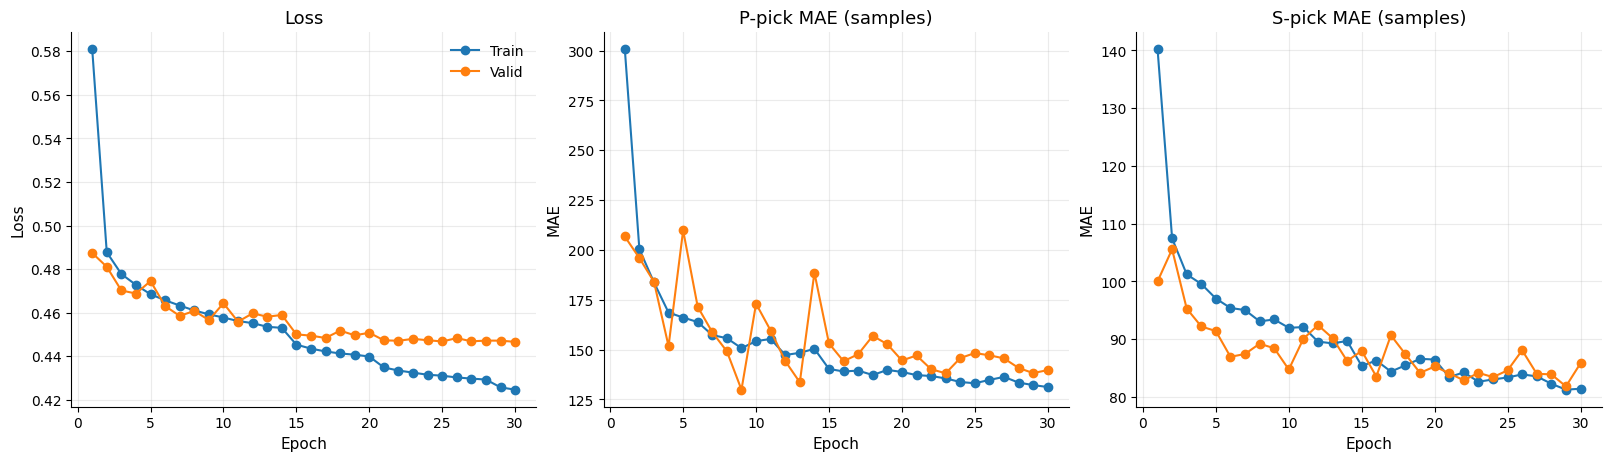

In [13]:

# =========================
# 13. Learning curves
# =========================
epochs = np.arange(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs, history["valid_loss"], marker="o", label="Valid")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(frameon=False)

axes[1].plot(epochs, history["train_p_mae"], marker="o", label="Train")
axes[1].plot(epochs, history["valid_p_mae"], marker="o", label="Valid")
axes[1].set_title("P-pick MAE (samples)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")

axes[2].plot(epochs, history["train_s_mae"], marker="o", label="Train")
axes[2].plot(epochs, history["valid_s_mae"], marker="o", label="Valid")
axes[2].set_title("S-pick MAE (samples)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("MAE")

plt.show()



## Final test evaluation

After training, we reload the **best validation model** and evaluate on the held-out test set.

We report:

- MAE in samples
- MAE in seconds
- accuracy within tolerance windows (for example ±10, ±20, ±50 samples)


In [14]:

# =========================
# 14. Test evaluation
# =========================
best_model = UNet1DPicker(in_ch=3, out_ch=2, base=24).to(DEVICE)
best_model.load_state_dict(torch.load(cfg.save_best_model, map_location=DEVICE))
best_model.eval()

test_loss_dict, test_metric_dict = run_one_epoch(best_model, test_loader, optimizer=None)

print("Test loss metrics:")
for k, v in test_loss_dict.items():
    print(f"  {k:>12s}: {v:.6f}")

print("\nTest picking metrics:")
for k, v in test_metric_dict.items():
    if "acc@" in k:
        print(f"  {k:>12s}: {100*v:.2f}%")
    else:
        print(f"  {k:>12s}: {v:.6f}")


Test loss metrics:
          loss: 0.449480
           bce: 0.022293
          dice: 0.427186

Test picking metrics:
  p_mae_samples: 133.486322
  s_mae_samples: 88.921526
  p_mae_seconds: 1.334863
  s_mae_seconds: 0.889215
      p_acc@10: 71.16%
      s_acc@10: 59.24%
      p_acc@20: 82.00%
      s_acc@20: 75.49%
      p_acc@50: 88.60%
      s_acc@50: 87.27%



## Qualitative prediction examples

A good arrival-picking workflow should not only score well numerically, but also produce interpretable probability curves.

Below we visualize for a few test samples:

- the 3-component waveform
- ground-truth P and S picks
- predicted P and S picks
- predicted probability curves


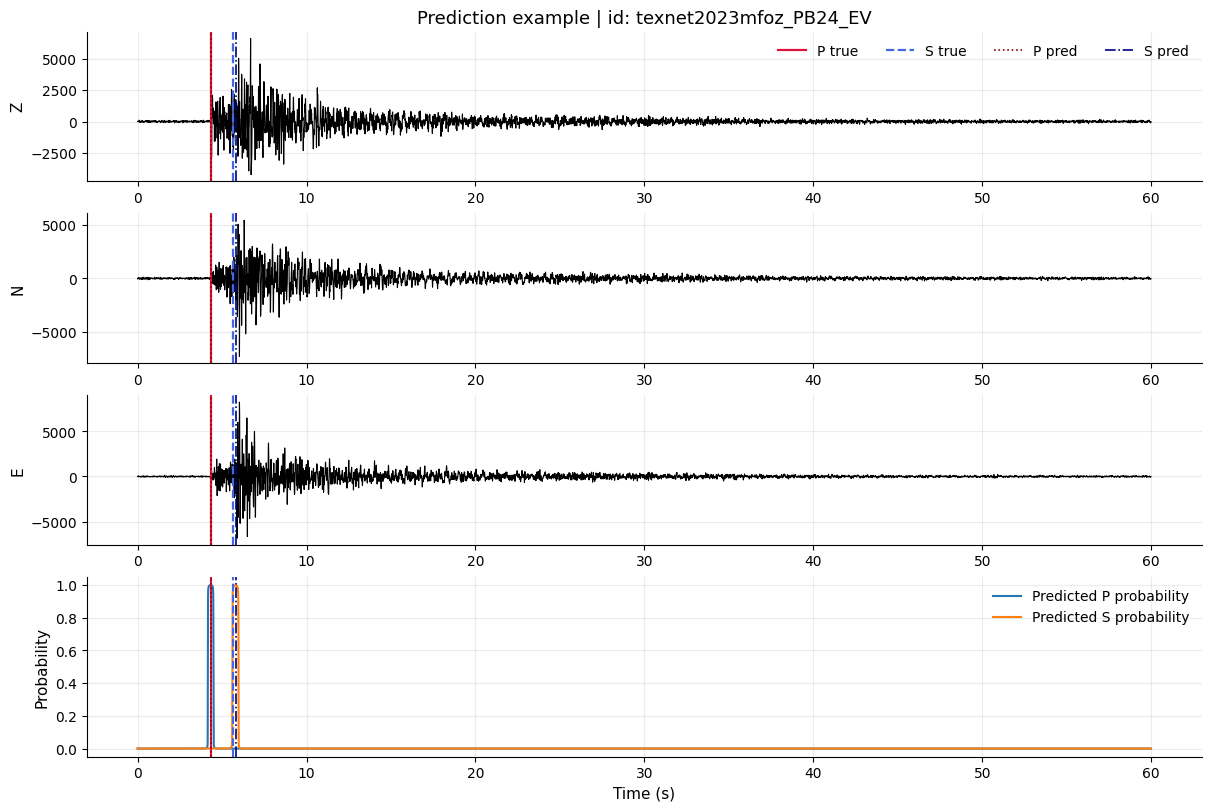

id=texnet2023mfoz_PB24_EV
  P true= 433, P pred= 433, abs err=   0 samples (0.000 s)
  S true= 564, S pred= 581, abs err=  17 samples (0.170 s)


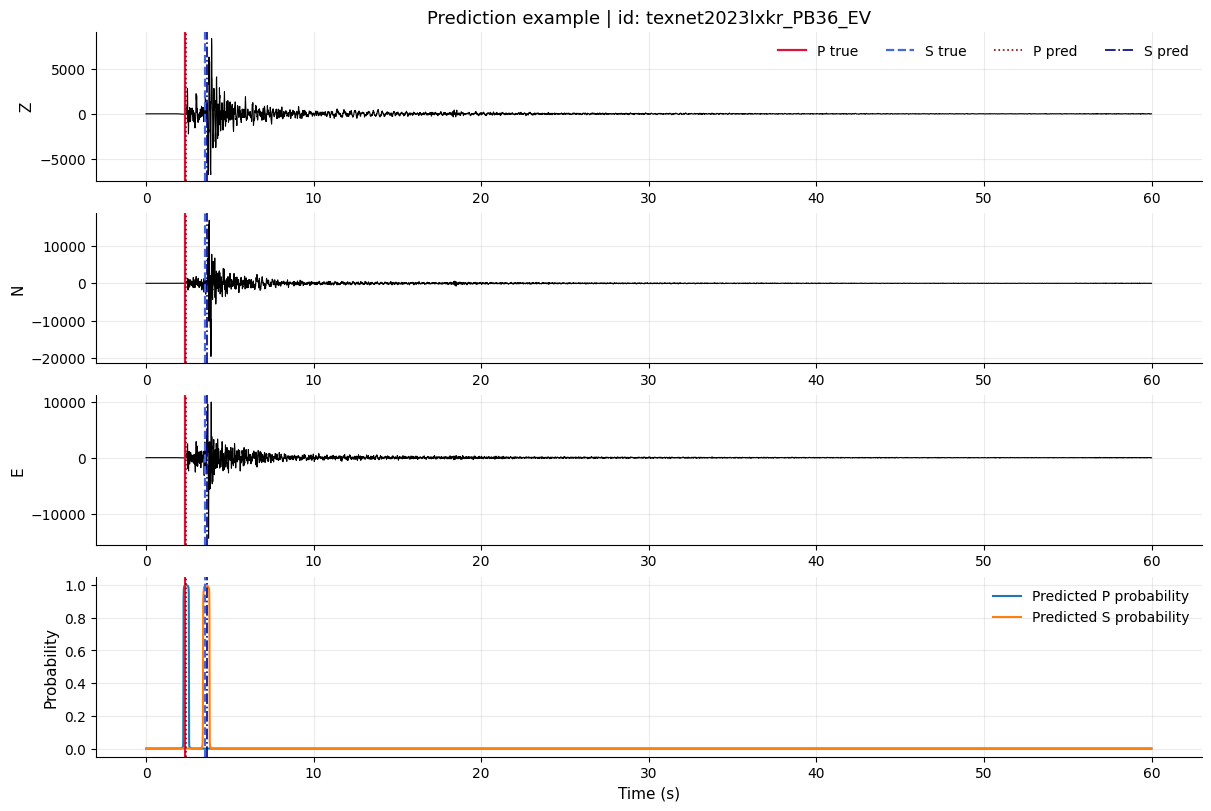

id=texnet2023lxkr_PB36_EV
  P true= 234, P pred= 240, abs err=   6 samples (0.060 s)
  S true= 352, S pred= 362, abs err=  10 samples (0.100 s)


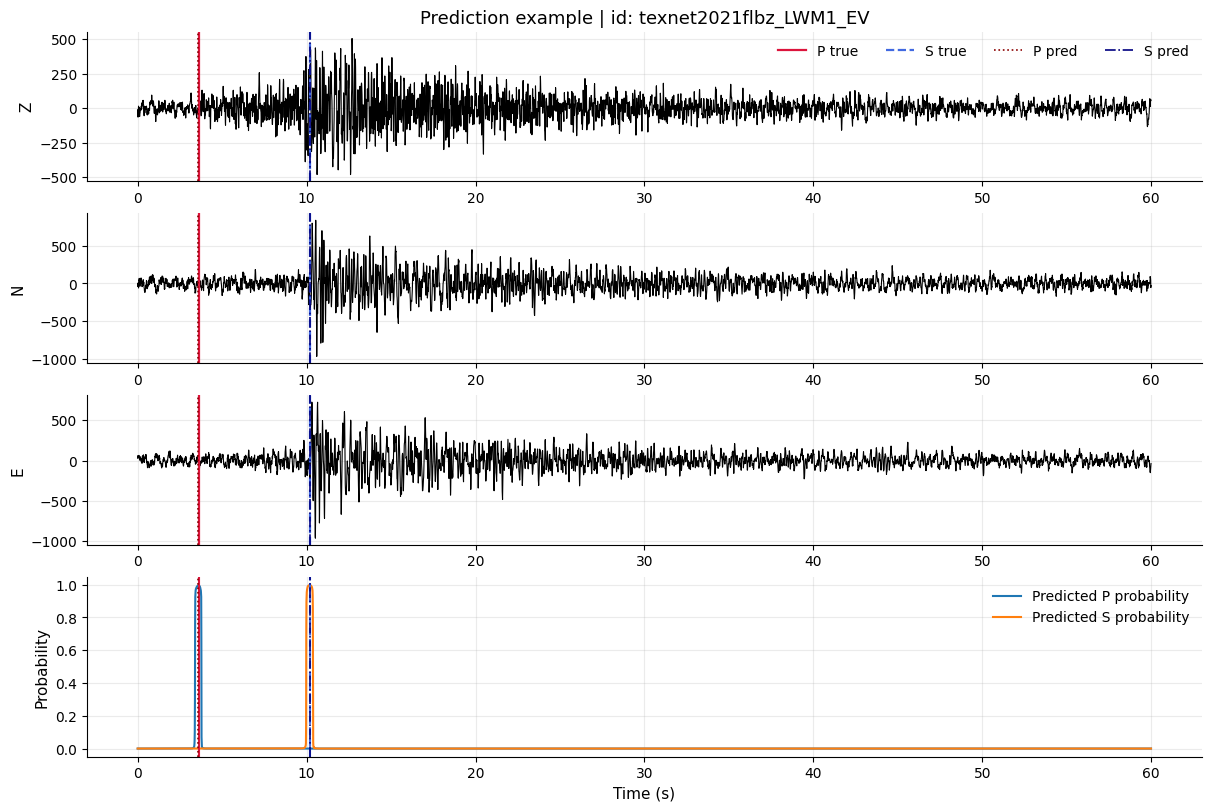

id=texnet2021flbz_LWM1_EV
  P true= 360, P pred= 359, abs err=   1 samples (0.010 s)
  S true=1019, S pred=1021, abs err=   2 samples (0.020 s)


In [15]:

# =========================
# 15. Prediction visualization
# =========================
@torch.no_grad()
def predict_one(model, x_np):
    # x_np: (T, 3)
    x = x_np.copy().astype(np.float32)
    mu = x.mean()
    std = x.std()
    x = (x - mu) / (std + 1e-6)
    if cfg.clip_value is not None:
        x = np.clip(x, -cfg.clip_value, cfg.clip_value)

    xt = torch.from_numpy(x.T).float().unsqueeze(0).to(DEVICE)
    logits = model(xt)
    p_pred, s_pred, prob = picks_from_logits(logits)
    p_pred = int(p_pred[0].cpu().item())
    s_pred = int(s_pred[0].cpu().item())
    prob = prob[0].cpu().numpy()    # (2, T)
    return p_pred, s_pred, prob

def plot_prediction_example(x, p_true, s_true, p_pred, s_pred, prob, fs=100.0, sample_id=None):
    t = np.arange(len(x)) / fs
    fig = plt.figure(figsize=(12, 8), constrained_layout=True)
    gs = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 1.2])

    axes = [fig.add_subplot(gs[i, 0]) for i in range(4)]

    for k in range(3):
        ax = axes[k]
        ax.plot(t, x[:, k], color="black", lw=0.8)
        ax.axvline(p_true / fs, color="crimson", lw=1.6, label="P true" if k == 0 else None)
        ax.axvline(s_true / fs, color="royalblue", lw=1.6, ls="--", label="S true" if k == 0 else None)
        ax.axvline(p_pred / fs, color="darkred", lw=1.2, ls=":", label="P pred" if k == 0 else None)
        ax.axvline(s_pred / fs, color="navy", lw=1.2, ls="-.", label="S pred" if k == 0 else None)
        ax.set_ylabel(COMPONENT_NAMES[k])
        if k == 0:
            ax.legend(frameon=False, ncol=4, loc="upper right")

    axes[3].plot(t, prob[0], lw=1.5, label="Predicted P probability")
    axes[3].plot(t, prob[1], lw=1.5, label="Predicted S probability")
    axes[3].axvline(p_true / fs, color="crimson", lw=1.5)
    axes[3].axvline(s_true / fs, color="royalblue", lw=1.5, ls="--")
    axes[3].axvline(p_pred / fs, color="darkred", lw=1.2, ls=":")
    axes[3].axvline(s_pred / fs, color="navy", lw=1.2, ls="-.")
    axes[3].set_ylabel("Probability")
    axes[3].set_xlabel("Time (s)")
    axes[3].legend(frameon=False, loc="upper right")

    title = "Prediction example"
    if sample_id is not None:
        title += f" | id: {sample_id}"
    axes[0].set_title(title)
    plt.show()

# choose a few test examples
rng = np.random.default_rng(SEED + 1)
show_n = min(3, len(idx_test))
picked = rng.choice(len(idx_test), size=show_n, replace=False)

for j in picked:
    real_idx = idx_test[j]
    x = waveforms[real_idx]
    p_true = int(P_idx[real_idx])
    s_true = int(S_idx[real_idx])
    sample_id = ids[real_idx]
    p_pred, s_pred, prob = predict_one(best_model, x)
    plot_prediction_example(x, p_true, s_true, p_pred, s_pred, prob, cfg.sampling_rate, sample_id)

    print(f"id={sample_id}")
    print(f"  P true={p_true:4d}, P pred={p_pred:4d}, abs err={abs(p_pred-p_true):4d} samples ({abs(p_pred-p_true)/cfg.sampling_rate:.3f} s)")
    print(f"  S true={s_true:4d}, S pred={s_pred:4d}, abs err={abs(s_pred-s_true):4d} samples ({abs(s_pred-s_true)/cfg.sampling_rate:.3f} s)")



## Optional extension ideas (Homework?)

This notebook is intentionally designed to be educational and practical.  
Several natural extensions can further improve performance or research depth.

### 1. Stronger architectures
You can replace the current model with:

- residual 1D U-Net
- temporal convolution network (TCN)
- bidirectional LSTM / GRU heads
- transformer encoders
- PhaseNet-style encoder–decoder variants

### 2. Better labels
Instead of Gaussian targets, you can experiment with:

- triangular windows
- Laplacian targets
- asymmetric labels
- uncertainty-aware soft targets

### 3. Additional losses
Possible alternatives include:

- focal loss
- Lovász-type overlap loss
- direct pick regression loss added to the probability loss
- consistency regularization

### 4. Better evaluation
In addition to MAE, you may report:

- median absolute error
- robustness to low-SNR traces
- performance as a function of S–P time
- confidence thresholding behavior

### 5. Seismology-specific improvements
Potential domain-aware ideas include:

- filtering or bandpass augmentation
- station-aware metadata fusion
- component-wise attention
- event distance or magnitude conditioning



## Practical interpretation

This workflow can be summarized as:

1. load 3-component seismograms,
2. represent arrivals as smooth target probability curves,
3. train a 1D U-Net to predict P and S probabilities,
4. extract picks by locating probability maxima,
5. validate performance numerically and visually.

In compact mathematical form, we solve

$$
\theta^\star
=
\arg\min_\theta
\frac{1}{N}
\sum_{i=1}^{N}
\mathcal{L}\!\left(
f_\theta(\mathbf{x}_i),\,
\mathbf{y}_i
\right),
$$

where $\mathbf{x}_i$ is the 3-component waveform and $\mathbf{y}_i$ contains the Gaussian target curves for the P and S arrivals.

---

## Brief Conclusion

This notebook provides a solid baseline for supervised arrival picking on `SWAN_real_arrival.npz`, while remaining simple enough to study, modify, and teach.
